In [1]:
import os, sys, shutil

# 1. Install the package missing from Kaggle's base image
!pip install -q -U "accelerate>=1.1.0"

# 2. Recreate the repo structure this notebook expects, under /kaggle/working
REPO_ROOT = '/kaggle/working/NLP-Ensemble'
SRC_INPUT = '/kaggle/input/datasets/armanbijari/nlp-ensemble-parsbert-cache'

os.makedirs(os.path.join(REPO_ROOT, 'data', 'processed'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'outputs', 'results'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'outputs', 'figures'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'src'), exist_ok=True)

shutil.copytree(f'{SRC_INPUT}/src', f'{REPO_ROOT}/src', dirs_exist_ok=True)
shutil.copytree(f'{SRC_INPUT}/data/processed', f'{REPO_ROOT}/data/processed', dirs_exist_ok=True)
shutil.copytree(f'{SRC_INPUT}/outputs/results', f'{REPO_ROOT}/outputs/results', dirs_exist_ok=True)

for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

print('REPO_ROOT set up at:', REPO_ROOT)
print(os.listdir(REPO_ROOT))
print(os.listdir(os.path.join(REPO_ROOT, 'data', 'processed')))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 6.6 MB/s eta 0:00:00
REPO_ROOT set up at: /kaggle/working/NLP-Ensemble
['src', 'data', 'outputs']
['y_test.npy', 'X_test_bert.npy', 'test.csv', 'y_train.npy', 'train.csv', 'X_train_bert.npy']


In [2]:
DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
for d in (RES_DIR, CM_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

print('DATA_PROC:', DATA_PROC)
print('RES_DIR:', RES_DIR)

DATA_PROC: /kaggle/working/NLP-Ensemble/data/processed
RES_DIR: /kaggle/working/NLP-Ensemble/outputs/results


In [3]:
import json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline      import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import (StackingClassifier, RandomForestClassifier,
                                   HistGradientBoostingClassifier)

from bert_features import ParsBertFeatureExtractor
from evaluation    import (evaluate_model, plot_confusion_matrix,
                           full_report, print_metrics_table, save_results_csv)

print('Imports OK')

# ---- Section 1: Load RAW text + labels ----
train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'), encoding='utf-8')
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'),  encoding='utf-8')

train_texts = train_df['comment'].fillna('').astype(str).tolist()
test_texts  = test_df['comment'].fillna('').astype(str).tolist()

y_train_path = os.path.join(DATA_PROC, 'y_train.npy')
y_test_path  = os.path.join(DATA_PROC, 'y_test.npy')

if os.path.exists(y_train_path) and os.path.exists(y_test_path):
    y_train = np.load(y_train_path)
    y_test  = np.load(y_test_path)
else:
    print("y_train.npy / y_test.npy not found — falling back to the CSV 'label' column.")
    y_train = train_df['label'].to_numpy()
    y_test  = test_df['label'].to_numpy()

print(f'Train reviews: {len(train_texts):,}   Test reviews: {len(test_texts):,}')
print(f'Example raw comment: {train_texts[0][:120]}')

# ---- Section 2: Load cached frozen ParsBERT features ----
X_train_bert_path = os.path.join(DATA_PROC, 'X_train_bert.npy')
X_test_bert_path  = os.path.join(DATA_PROC, 'X_test_bert.npy')

if os.path.exists(X_train_bert_path) and os.path.exists(X_test_bert_path):
    X_train_bert = np.load(X_train_bert_path)
    X_test_bert  = np.load(X_test_bert_path)
    print('Loaded cached ParsBERT features.')
else:
    enc = ParsBertFeatureExtractor(max_length=128, batch_size=32, pooling='mean')
    print(f'Encoding with frozen ParsBERT on device: {enc._device or "auto"} ...')
    t0 = time.time()
    X_train_bert = enc.transform(train_texts)
    X_test_bert  = enc.transform(test_texts)
    print(f'Encoding done in {time.time() - t0:.1f}s')
    np.save(X_train_bert_path, X_train_bert)
    np.save(X_test_bert_path,  X_test_bert)

print(f'Feature shapes: train {X_train_bert.shape}, test {X_test_bert.shape}')

Imports OK
Train reviews: 55,583   Test reviews: 13,896
Example raw comment: سلام دستم اشتباهی خورد روی ناراضی در صورتیکه از همه چیز راضی بودم
Loaded cached ParsBERT features.
Feature shapes: train (55583, 768), test (13896, 768)


In [4]:
REP = 'ParsBERT-frozen'
bert_results = []

heads = {
    'SVM (Linear)': make_pipeline(
        StandardScaler(),
        CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000)),
    ),
    'LogisticRegression': make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', n_jobs=-1),
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.08, random_state=42,
    ),
}

for name, clf in heads.items():
    t0 = time.time()
    clf.fit(X_train_bert, y_train)
    y_pred = clf.predict(X_test_bert)
    metrics = evaluate_model(name, REP, y_test, y_pred)
    metrics['train_time_s'] = round(time.time() - t0, 1)
    bert_results.append(metrics)
    print(f"{name:<22} F1={metrics['f1']:.4f}  acc={metrics['accuracy']:.4f}  "
          f"({metrics['train_time_s']}s)")

print()
print_metrics_table(bert_results)

SVM (Linear)           F1=0.8445  acc=0.8447  (92.0s)
LogisticRegression     F1=0.8438  acc=0.8440  (9.8s)
HistGradientBoosting   F1=0.8357  acc=0.8361  (53.6s)

               model      vectorizer accuracy precision recall     f1
        SVM (Linear) ParsBERT-frozen   84.47%    84.69% 84.47% 84.45%
  LogisticRegression ParsBERT-frozen   84.40%    84.61% 84.40% 84.38%
HistGradientBoosting ParsBERT-frozen   83.61%    83.94% 83.61% 83.57%


Stacking on ParsBERT  F1=0.8450  acc=0.8452  (3632.9s)

Model: Stacking   |   Vectorizer: ParsBERT-frozen
              precision    recall  f1-score   support

         Sad       0.82      0.88      0.85      6913
       Happy       0.87      0.81      0.84      6983

    accuracy                           0.85     13896
   macro avg       0.85      0.85      0.85     13896
weighted avg       0.85      0.85      0.85     13896



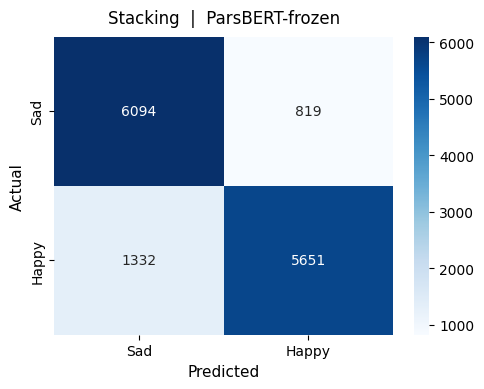

In [5]:
bert_base = [
    ('svm', make_pipeline(StandardScaler(),
                          CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000)))),
    ('lr',  make_pipeline(StandardScaler(),
                          LogisticRegression(C=1.0, max_iter=2000, n_jobs=1))),
    ('hgb', HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=300, n_jobs=1, random_state=42)),
]

bert_stack = StackingClassifier(
    estimators=bert_base,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000),
    cv=5, stack_method='auto', n_jobs=2, passthrough=False,
)

t0 = time.time()
bert_stack.fit(X_train_bert, y_train)
y_pred_stack = bert_stack.predict(X_test_bert)
stack_metrics = evaluate_model('Stacking', REP, y_test, y_pred_stack)
stack_metrics['train_time_s'] = round(time.time() - t0, 1)
bert_results.append(stack_metrics)

print(f"Stacking on ParsBERT  F1={stack_metrics['f1']:.4f}  "
      f"acc={stack_metrics['accuracy']:.4f}  ({stack_metrics['train_time_s']}s)")
full_report('Stacking', REP, y_test, y_pred_stack)
plot_confusion_matrix('Stacking', REP, y_test, y_pred_stack, CM_DIR, show=True)

In [6]:
rows = []

p3_path = os.path.join(RES_DIR, 'phase3_results.csv')
if os.path.exists(p3_path):
    p3 = pd.read_csv(p3_path)
    best3 = p3.loc[p3['f1'].idxmax()]
    rows.append({'Stage': 'Classical best single',
                 'Model': f"{best3['model']} / {best3['vectorizer']}",
                 'Accuracy': round(float(best3['accuracy']), 4),
                 'F1': round(float(best3['f1']), 4)})

p5_path = os.path.join(RES_DIR, 'phase5_stacking_results.json')
if os.path.exists(p5_path):
    with open(p5_path, encoding='utf-8') as f:
        p5 = json.load(f)
    rows.append({'Stage': 'Classical stacking',
                 'Model': f"Stacking / {p5['vectorizer_used']}",
                 'Accuracy': p5['stacking_accuracy'], 'F1': p5['stacking_f1']})

best_bert = max(bert_results, key=lambda r: r['f1'])
for r in bert_results:
    rows.append({'Stage': f"ParsBERT — {r['model']}",
                 'Model': f"{r['model']} / {REP}",
                 'Accuracy': r['accuracy'], 'F1': r['f1']})

cmp_df = pd.DataFrame(rows).sort_values('F1').reset_index(drop=True)
print(cmp_df.to_string(index=False))
print()
if rows and len(rows) >= 2:
    classical_best = max((r['F1'] for r in rows if 'ParsBERT' not in r['Stage']), default=0.0)
    print(f"Best classical F1 : {classical_best:.4f}")
    print(f"Best ParsBERT F1  : {best_bert['f1']:.4f}")
    print(f"Gain from context : {best_bert['f1'] - classical_best:+.4f}")

                          Stage                                  Model  Accuracy     F1
ParsBERT — HistGradientBoosting HistGradientBoosting / ParsBERT-frozen    0.8361 0.8357
  ParsBERT — LogisticRegression   LogisticRegression / ParsBERT-frozen    0.8440 0.8438
        ParsBERT — SVM (Linear)         SVM (Linear) / ParsBERT-frozen    0.8447 0.8445
            ParsBERT — Stacking             Stacking / ParsBERT-frozen    0.8452 0.8450
          Classical best single          SVM (Linear) (tuned) / Hybrid    0.8578 0.8574
             Classical stacking                      Stacking / Hybrid    0.8580 0.8578

Best classical F1 : 0.8578
Best ParsBERT F1  : 0.8450
Gain from context : -0.0128


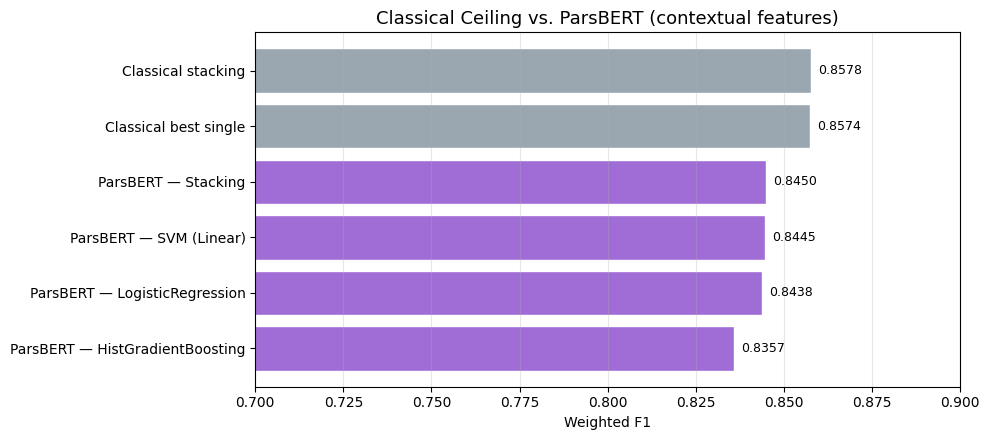

[evaluation] Results saved to /kaggle/working/NLP-Ensemble/outputs/results/phase6_bert_results.csv
Saved: outputs/results/phase6_bert_results.csv
Saved: outputs/results/phase6_bert_summary.json


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = cmp_df.sort_values('F1', ascending=True)
colors = ['#9aa7b1' if 'ParsBERT' not in s else '#A06CD5' for s in order['Stage']]
ax.barh(order['Stage'], order['F1'], color=colors, edgecolor='white')
for y, v in enumerate(order['F1']):
    ax.text(v + 0.002, y, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlim(0.7, max(0.9, order['F1'].max() + 0.03))
ax.set_xlabel('Weighted F1')
ax.set_title('Classical Ceiling vs. ParsBERT (contextual features)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'parsbert_vs_classical.png'), dpi=120, bbox_inches='tight')
plt.show()

save_results_csv(bert_results, os.path.join(RES_DIR, 'phase6_bert_results.csv'))

summary = {
    'representation':   REP,
    'best_bert_model':  best_bert['model'],
    'best_bert_f1':     best_bert['f1'],
    'best_bert_accuracy': best_bert['accuracy'],
    'all_results':      bert_results,
}
with open(os.path.join(RES_DIR, 'phase6_bert_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved: outputs/results/phase6_bert_results.csv')
print('Saved: outputs/results/phase6_bert_summary.json')

train_base: 50,024 rows   blend: 5,559 rows


config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Fine-tuned ParsBERT   F1=0.8730  acc=0.8731


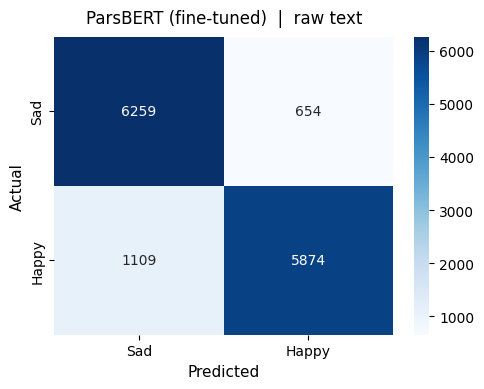

Saved: outputs/results/phase6_finetune_results.json
Saved: data/processed/P_blend_bert_ft.npy, P_test_bert_ft.npy (for Section 6.5)


In [8]:
RUN_FINETUNE = True  # set True on a GPU machine to fine-tune end-to-end

from sklearn.model_selection import train_test_split

idx_all = np.arange(len(y_train))
idx_base, idx_blend = train_test_split(
    idx_all, test_size=0.10, stratify=y_train, random_state=42,
)
y_train_base = y_train[idx_base]
y_blend      = y_train[idx_blend]
print(f'train_base: {len(idx_base):,} rows   blend: {len(idx_blend):,} rows')

if RUN_FINETUNE:
    import torch
    from torch.utils.data import Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    from sklearn.metrics import accuracy_score, f1_score

    MODEL_NAME = 'HooshvareLab/bert-base-parsbert-uncased'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_base_texts = [train_texts[i] for i in idx_base]
    blend_texts       = [train_texts[i] for i in idx_blend]

    class ReviewDataset(Dataset):
        def __init__(self, texts, labels, tok, max_length=128):
            self.enc = tok(list(texts), truncation=True, padding=True,
                           max_length=max_length)
            self.labels = list(labels)
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(int(self.labels[i]))
            return item

    train_base_ds = ReviewDataset(train_base_texts, y_train_base, tokenizer)
    blend_ds      = ReviewDataset(blend_texts,       y_blend,      tokenizer)
    test_ds       = ReviewDataset(test_texts,        y_test,       tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        return {'accuracy': accuracy_score(labels, preds),
                'f1': f1_score(labels, preds, average='weighted')}

    args = TrainingArguments(
        output_dir=os.path.join(REPO_ROOT, 'outputs', 'parsbert_finetune'),
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_steps=200,
        report_to='none',
        seed=42,
    )

    trainer = Trainer(model=model, args=args, train_dataset=train_base_ds,
                      eval_dataset=blend_ds, compute_metrics=compute_metrics)
    trainer.train()

    blend_logits = trainer.predict(blend_ds).predictions
    test_logits  = trainer.predict(test_ds).predictions

    P_blend_bert_ft = torch.softmax(torch.tensor(blend_logits), dim=1).numpy()
    P_test_bert_ft  = torch.softmax(torch.tensor(test_logits),  dim=1).numpy()

    y_pred_ft = P_test_bert_ft.argmax(axis=1)
    ft_metrics = evaluate_model('ParsBERT (fine-tuned)', 'raw text', y_test, y_pred_ft)
    print(f"Fine-tuned ParsBERT   F1={ft_metrics['f1']:.4f}  acc={ft_metrics['accuracy']:.4f}")
    plot_confusion_matrix('ParsBERT (fine-tuned)', 'raw text', y_test, y_pred_ft, CM_DIR, show=True)

    np.save(os.path.join(DATA_PROC, 'P_blend_bert_ft.npy'), P_blend_bert_ft)
    np.save(os.path.join(DATA_PROC, 'P_test_bert_ft.npy'),  P_test_bert_ft)

    with open(os.path.join(RES_DIR, 'phase6_finetune_results.json'), 'w', encoding='utf-8') as f:
        json.dump({k: float(v) for k, v in ft_metrics.items() if isinstance(v, (int, float))},
                  f, indent=2)
    print('Saved: outputs/results/phase6_finetune_results.json')
    print('Saved: data/processed/P_blend_bert_ft.npy, P_test_bert_ft.npy (for Section 6.5)')
else:
    print('RUN_FINETUNE is False — skipping.')

Hybrid (train_base fit): (50024, 94922)
Plain word TF-IDF (train_base fit): (50024, 48057)

Extended ensemble members: ['SVM / Hybrid', 'LogReg / Hybrid', 'HGB / ParsBERT-frozen', 'ComplementNB / word TF-IDF', 'ParsBERT (fine-tuned)']
Meta-feature shapes: blend (5559, 10), test (13896, 10)
Best meta-learner C: 0.3  (CV f1_weighted on blend = 0.8713)

Extended ensemble  F1=0.8713  acc=0.8714

Model: Extended ensemble (meta)   |   Vectorizer: mixed representations
              precision    recall  f1-score   support

         Sad       0.85      0.90      0.87      6913
       Happy       0.90      0.84      0.87      6983

    accuracy                           0.87     13896
   macro avg       0.87      0.87      0.87     13896
weighted avg       0.87      0.87      0.87     13896



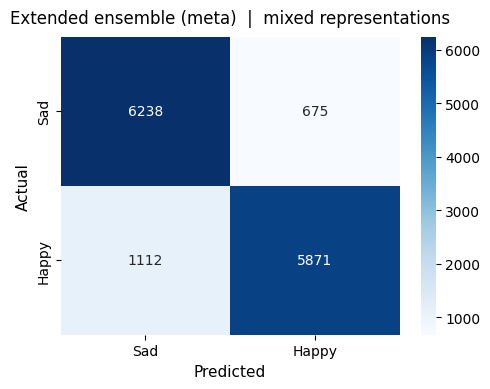


Meta-learner coefficients (one row per class, one column per member proba column):
[[-0.48195935  0.53801463 -0.42736248  0.48341776 -0.30590713  0.36196242
  -0.45626157  0.51231686 -1.40598993  1.46204525]]


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV
from vectorizers import build_word_char_union

# ---- 1. Cleaned text for train_base / blend / test, split by the SAME indices ----
train_cleaned = train_df['cleaned'].fillna('').astype(str).to_numpy()
test_cleaned  = test_df['cleaned'].fillna('').astype(str).to_numpy()

cleaned_base  = train_cleaned[idx_base]
cleaned_blend = train_cleaned[idx_blend]

# ---- 2. Hybrid word+char TF-IDF, fit on train_base ONLY (same sizing as NB02) ----
hybrid_vec = build_word_char_union(
    word_ngram_range=(1, 2), char_ngram_range=(2, 5),
    word_max_features=100_000, char_max_features=300_000,
    min_df=3, sublinear_tf=True,
)
X_base_hybrid  = hybrid_vec.fit_transform(cleaned_base)
X_blend_hybrid = hybrid_vec.transform(cleaned_blend)
X_test_hybrid  = hybrid_vec.transform(test_cleaned)
print(f'Hybrid (train_base fit): {X_base_hybrid.shape}')

# ---- 3. Plain word TF-IDF, fit on train_base ONLY ----
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                           max_features=100_000, min_df=3, sublinear_tf=True)
X_base_word  = word_vec.fit_transform(cleaned_base)
X_blend_word = word_vec.transform(cleaned_blend)
X_test_word  = word_vec.transform(test_cleaned)
print(f'Plain word TF-IDF (train_base fit): {X_base_word.shape}')

# ---- 4. Frozen ParsBERT features, sliced by the SAME train indices ----
X_base_bert  = X_train_bert[idx_base]
X_blend_bert = X_train_bert[idx_blend]
# X_test_bert already loaded in Section 2.

# ---- 5. Fit the four always-available base members on train_base ----
ext_members = {}

svm_hybrid = make_pipeline(CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=5000)))
svm_hybrid.fit(X_base_hybrid, y_train_base)
ext_members['SVM / Hybrid'] = (
    svm_hybrid.predict_proba(X_blend_hybrid), svm_hybrid.predict_proba(X_test_hybrid))

lr_hybrid = LogisticRegression(C=0.5, max_iter=3000, n_jobs=-1)
lr_hybrid.fit(X_base_hybrid, y_train_base)
ext_members['LogReg / Hybrid'] = (
    lr_hybrid.predict_proba(X_blend_hybrid), lr_hybrid.predict_proba(X_test_hybrid))

hgb_bert = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=42)
hgb_bert.fit(X_base_bert, y_train_base)
ext_members['HGB / ParsBERT-frozen'] = (
    hgb_bert.predict_proba(X_blend_bert), hgb_bert.predict_proba(X_test_bert))

nb_word = ComplementNB(alpha=0.25)
nb_word.fit(X_base_word, y_train_base)
ext_members['ComplementNB / word TF-IDF'] = (
    nb_word.predict_proba(X_blend_word), nb_word.predict_proba(X_test_word))

# ---- 6. Add the fine-tuned ParsBERT member if Section 6 produced it ----
p_blend_ft_path = os.path.join(DATA_PROC, 'P_blend_bert_ft.npy')
p_test_ft_path  = os.path.join(DATA_PROC, 'P_test_bert_ft.npy')

if 'P_blend_bert_ft' in dir() and 'P_test_bert_ft' in dir():
    ext_members['ParsBERT (fine-tuned)'] = (P_blend_bert_ft, P_test_bert_ft)
elif os.path.exists(p_blend_ft_path) and os.path.exists(p_test_ft_path):
    ext_members['ParsBERT (fine-tuned)'] = (
        np.load(p_blend_ft_path), np.load(p_test_ft_path))
else:
    print('[Section 6.5] Fine-tuned ParsBERT probabilities not found — running the '
          'ensemble with the remaining 4 members. Set RUN_FINETUNE = True in Section 6 '
          'to add this member.')

print(f"\nExtended ensemble members: {list(ext_members.keys())}")

# ---- 7. Build meta-feature matrices (concat each member's proba on blend / test) ----
meta_X_blend = np.hstack([p_blend for p_blend, _ in ext_members.values()])
meta_X_test  = np.hstack([p_test  for _, p_test  in ext_members.values()])
print(f'Meta-feature shapes: blend {meta_X_blend.shape}, test {meta_X_test.shape}')

# ---- 8. Fit the meta-learner on blend, tuning C by CV on blend only ----
meta_search = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid={'C': [0.1, 0.3, 1.0]},
    cv=5, scoring='f1_weighted', n_jobs=-1,
)
meta_search.fit(meta_X_blend, y_blend)
meta_clf = meta_search.best_estimator_
print(f'Best meta-learner C: {meta_search.best_params_["C"]}  '
      f'(CV f1_weighted on blend = {meta_search.best_score_:.4f})')

# ---- 9. Evaluate ONCE on test ----
y_pred_ext = meta_clf.predict(meta_X_test)
ext_metrics = evaluate_model('Extended ensemble (meta)', 'mixed representations',
                             y_test, y_pred_ext)
print(f"\nExtended ensemble  F1={ext_metrics['f1']:.4f}  acc={ext_metrics['accuracy']:.4f}")
full_report('Extended ensemble (meta)', 'mixed representations', y_test, y_pred_ext)
plot_confusion_matrix('Extended ensemble (meta)', 'mixed representations',
                      y_test, y_pred_ext, CM_DIR, show=True)

print('\nMeta-learner coefficients (one row per class, one column per member proba column):')
print(meta_clf.coef_)